### Super App Design Flowchart (Tree Visualization)

This section generates a static tree-like flowchart for a conceptual 'Super App' structure using `networkx` and `matplotlib`. Each node represents a component (e.g., app, industry segment, service).

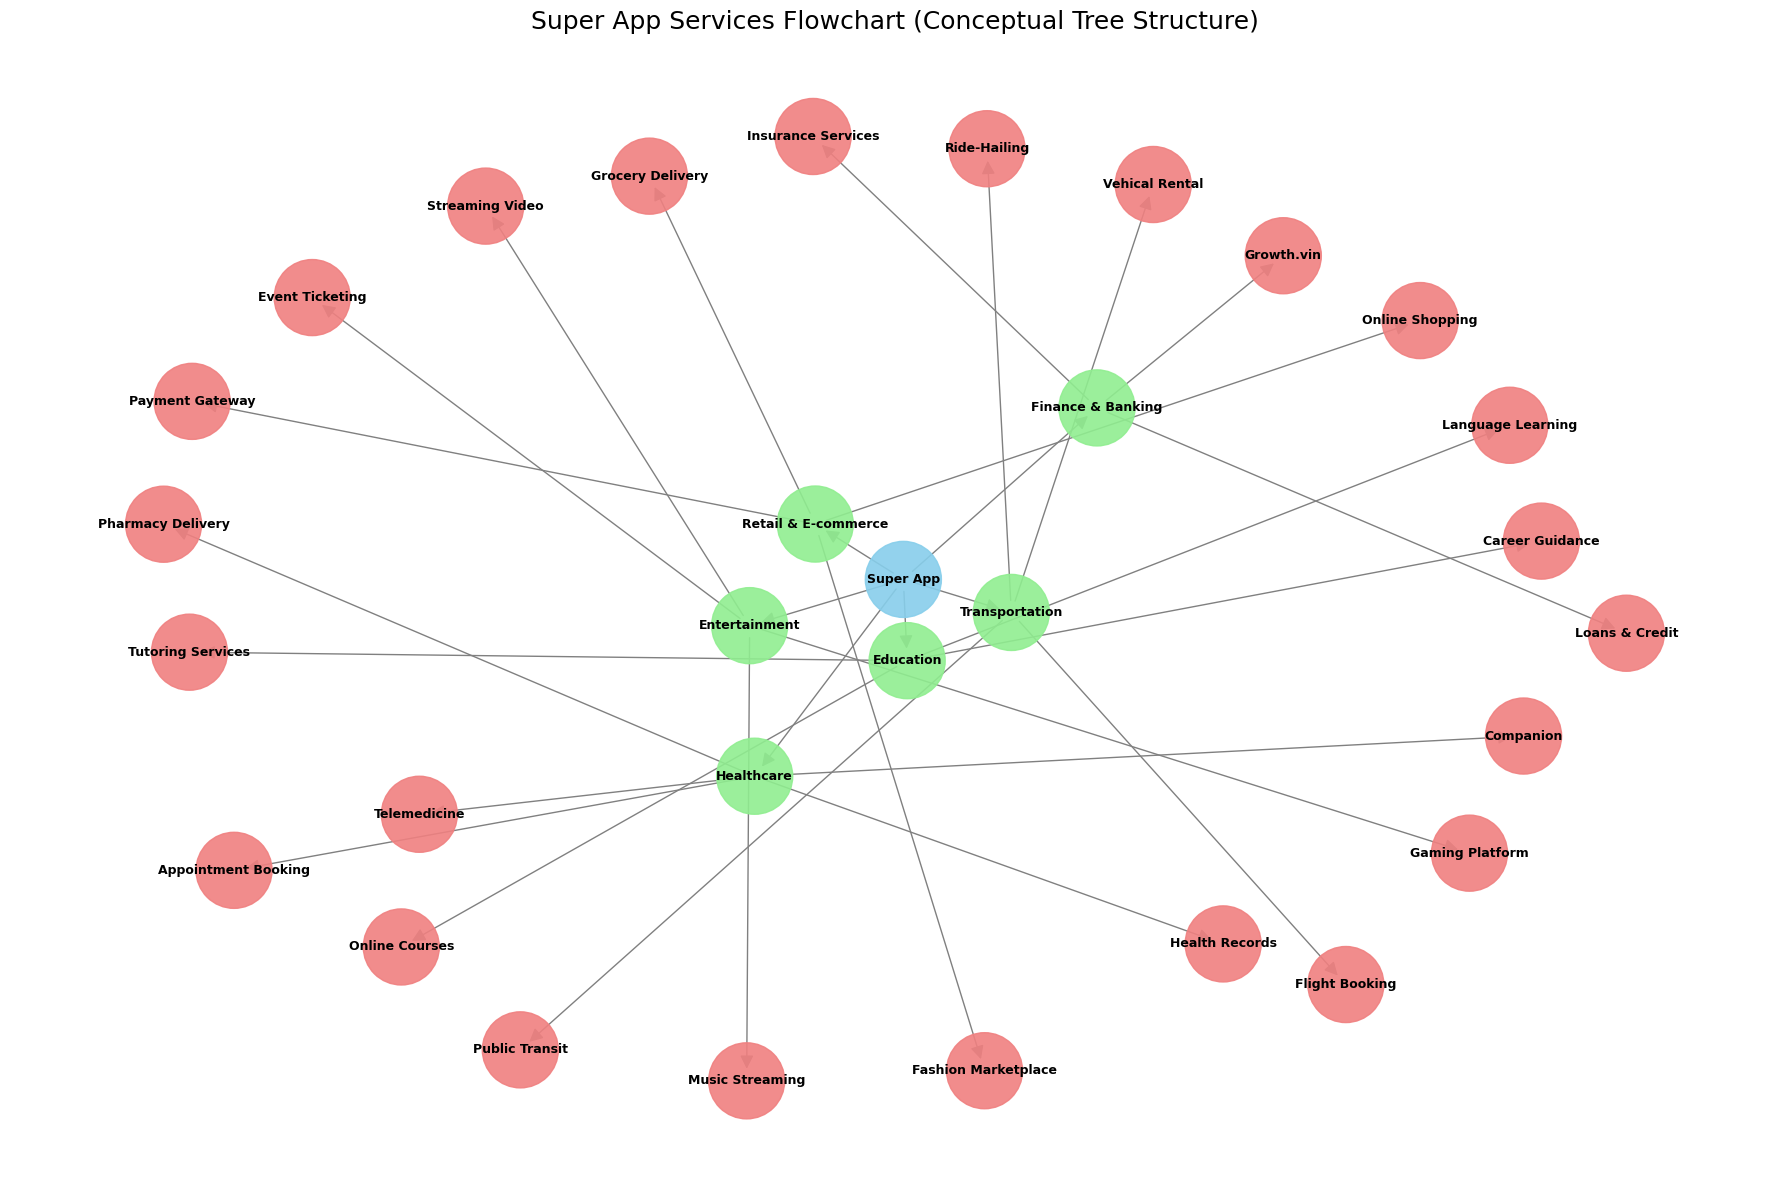

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph to represent the flowchart
G = nx.DiGraph()

# Add the main 'Super App' node
G.add_node('Super App', type='root')

# Add Industry Segments
industry_segments = [
    'Finance & Banking',
    'Retail & E-commerce',
    'Healthcare',
    'Transportation',
    'Education',
    'Entertainment'
]
for segment in industry_segments:
    G.add_node(segment, type='segment')
    G.add_edge('Super App', segment)

# Add example services for each segment
services_data = {
    'Finance & Banking': ['Growth.vin', 'Insurance Services', 'Loans & Credit'],
    'Retail & E-commerce': ['Online Shopping', 'Grocery Delivery', 'Fashion Marketplace', 'Payment Gateway'],
    'Healthcare': ['Telemedicine', 'Pharmacy Delivery', 'Appointment Booking', 'Health Records', 'Companion'],
    'Transportation': ['Ride-Hailing', 'Public Transit', 'Vehical Rental', 'Flight Booking'],
    'Education': ['Online Courses', 'Tutoring Services', 'Career Guidance', 'Language Learning'],
    'Eateries': ['Street Vendor', 'Restaurants', 'Star Hotels', 'Cloud Kitchens']
}

for segment, services in services_data.items():
    for service in services:
        G.add_node(service, type='service')
        G.add_edge(segment, service)

# Define node colors based on type
node_colors = []
for node in G.nodes():
    if G.nodes[node]['type'] == 'root':
        node_colors.append('skyblue')
    elif G.nodes[node]['type'] == 'segment':
        node_colors.append('lightgreen')
    else:
        node_colors.append('lightcoral')

# Draw the graph
plt.figure(figsize=(18, 12))
pos = nx.spring_layout(G, k=0.7, iterations=50) # Use a spring layout for better node separation

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title('Super App Services Flowchart (Conceptual Tree Structure)', size=18)
plt.axis('off') # Hide axes
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


In [10]:
import plotly.graph_objects as go

# Get node positions from the networkx layout
node_x = [pos[node][0] for node in G.nodes()]
node_y = [pos[node][1] for node in G.nodes()]

# Create edge traces
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None) # Separates lines
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

# Create node traces
node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers+text',
    hoverinfo='text',
    text=[node for node in G.nodes()],
    textposition='top center',
    marker=dict(
        showscale=False,
        size=20,
        colorbar=dict(
            thickness=15,
            title='Node Connections',
            xanchor='left',
            titleside='right'
        ),
        line_width=2,
        color=node_colors # Use the same coloring as before
    )
)

# Create the figure
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                 title='<br>Interactive Super App Services Flowchart',
                 titlefont_size=16,
                 showlegend=False,
                 hovermode='closest',
                 margin=dict(b=20,l=5,r=5,t=40),
                 annotations=[ dict(
                     text="", # Optional: Add source or explanation here
                     showarrow=False,
                     xref="paper", yref="paper",
                     x=0.005, y=-0.002 ) ],
                 xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                 yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
             )

fig.show()


In [11]:
!pip install dash

import dash
from dash import dcc
from dash import html

# Initialize the Dash app
app = dash.Dash(__name__)

# Define the app layout
app.layout = html.Div(children=[
    html.H1(children='Super App Services Flowchart Dashboard'),

    html.Div(children='''
        An interactive visualization of the Super App's structure.
    '''),

    dcc.Graph(
        id='super-app-flowchart',
        figure=fig # Use the Plotly figure generated in the previous cell
    )
])

# Run the app
if __name__ == '__main__':
    # In Colab, you might need to use a different method to expose the port
    # or run it with jupyter_dash. For simplicity, we'll use app.run_server
    # which will typically print a URL you can click if running locally.
    # For Colab specifically, a library like `jupyter_dash` is often used
    # or ngrok for external access.
    print("Running Dash app. Click the URL below once it appears (it might take a moment):")
    app.run_server(mode='inline', port=8050)

ModuleNotFoundError: No module named 'dash'

### Achieving Web-Workable, Animated, and Traceable Flowcharts

The static image above provides a basic tree visualization. For a truly "web-workable, animated, and traceable" flowchart with interactive features (like clicking on nodes to expand/collapse, showing detailed information, or animated transitions), you would typically need to integrate with web technologies.

Here are some approaches:

1.  **Generate HTML/JavaScript:** You could use Python to generate HTML and JavaScript code that leverages libraries like D3.js, vis.js, or GoJS. These libraries are specifically designed for interactive graph and flowchart visualizations in web browsers. The output HTML could then be saved and opened in a browser.

2.  **Dedicated Python Visualization Libraries:** Libraries like `Plotly` or `Dash` can create interactive web-based dashboards and visualizations directly from Python. While they might require more setup for complex tree layouts, they can render interactive graphs that are viewable within Colab (though running on a local server) or exported.

3.  **Export to Graph Description Languages:** You could export the `networkx` graph to formats like DOT (Graphviz), which can then be processed by other tools to generate various static or interactive outputs.

4.  **Colab-specific Interactive Libraries:** Look for any emerging Colab-friendly libraries that specifically offer interactive graph visualizations. However, these are less common for highly customized animated flowcharts.

If you'd like to explore generating a more interactive visualization, please specify which web library or framework you are interested in, and I can try to provide code that generates the necessary data structure or a basic interactive plot.